# 00 数据盘点：美团外卖订单超时分析与高峰期骑手运力配置

本 Notebook 对公开数据做接手阶段的数据验收，回答四个问题：

1. 四张表分别是什么粒度，主键是否唯一？
2. `0` 是否被用作业务缺失值，能否直接按普通数值参与分析？
3. 一张订单是否会有多张运单，哪一行才代表最终履约结果？
4. 表之间应该怎样连接，哪些连接会造成多对多膨胀？

## 管理摘要

- 运单表有 **654,343 行、568,546 个订单**；其粒度是“运单尝试”，不是“一行一个订单”。
- **57,770 个订单**存在多次派单尝试，但每个订单恰好只有一张被骑手接受的运单，可据此构造订单级履约样本。
- 数据覆盖 **2022-10-17 至 2022-10-24 共 8 个业务日期**。按 `arrive_time <= estimate_arrived_time` 计算的初步准时率为 **84.99%**，但该数值在冻结样本规则前仅用于数据验收。
- 原始空值率为 0 不代表没有缺失：拒绝运单的接单、取餐、送达时间用 `0` 编码，`da_id`、`poi_id` 等字段也存在语义性 `0`。
- 派单订单表和候选骑手表记录的是 **24 个调度决策时点的两个快照集合**。只按 `dispatch_time` 直接连接会产生约 **4,117 万行**，不能当成订单—骑手一一对应关系。

## 1. 环境与数据源

数据源：Meituan-INFORMS-TSL Research Challenge 官方公开仓库。官方论文说明该数据来自中国某匿名中等规模城市，包含 568,546 个订单、4,955 名骑手、4,962 家商户；调度快照为 8 天午高峰、每天 3 个决策时点。

本地只读取原始文件，不覆盖原始数据。

In [1]:
from pathlib import Path
import ast
import json

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW = PROJECT_ROOT / "data" / "raw" / "downloads"
paths = {
    "waybill": RAW / "waybill_extracted" / "all_waybill_info_meituan_0322.csv",
    "courier_wave": RAW / "courier_wave_info_meituan.csv",
    "dispatch_rider": RAW / "dispatch_rider_meituan.csv",
    "dispatch_waybill": RAW / "dispatch_waybill_meituan.csv",
}

for name, path in paths.items():
    assert path.exists(), f"Missing {name}: {path}"

print("Input validation passed: 4 required source tables found.")

Input validation passed: 4 required source tables found.


In [2]:
waybill = pd.read_csv(paths["waybill"]).rename(columns={"Unnamed: 0": "source_row_id"})
courier_wave = pd.read_csv(paths["courier_wave"])
dispatch_rider = pd.read_csv(paths["dispatch_rider"]).rename(columns={"Unnamed: 0": "source_row_id"})
dispatch_waybill = pd.read_csv(paths["dispatch_waybill"]).rename(columns={"Unnamed: 0": "source_row_id"})

tables = {
    "waybill": waybill,
    "courier_wave": courier_wave,
    "dispatch_rider": dispatch_rider,
    "dispatch_waybill": dispatch_waybill,
}

pd.DataFrame(
    [{"table": name, "rows": len(df), "columns": df.shape[1]} for name, df in tables.items()]
).set_index("table")

,rows,columns
table,,
waybill,654343,24
courier_wave,206748,6
dispatch_rider,62044,7
dispatch_waybill,15921,4


## 2. 表粒度与候选主键

在真实业务中，先确认 grain（每一行代表什么）再做指标。这里最容易犯的错误，是把 `order_id` 当作运单表主键。

In [3]:
key_checks = pd.DataFrame([
    {
        "table": "waybill",
        "candidate_key": "waybill_id",
        "duplicate_rows": int(waybill.duplicated(["waybill_id"], keep=False).sum()),
        "grain": "one dispatch attempt / waybill",
    },
    {
        "table": "courier_wave",
        "candidate_key": "dt + courier_id + wave_id",
        "duplicate_rows": int(courier_wave.duplicated(["dt", "courier_id", "wave_id"], keep=False).sum()),
        "grain": "one courier wave",
    },
    {
        "table": "dispatch_rider",
        "candidate_key": "dt + dispatch_time + courier_id",
        "duplicate_rows": int(dispatch_rider.duplicated(["dt", "dispatch_time", "courier_id"], keep=False).sum()),
        "grain": "one candidate courier at one decision epoch",
    },
    {
        "table": "dispatch_waybill",
        "candidate_key": "dt + dispatch_time + order_id",
        "duplicate_rows": int(dispatch_waybill.duplicated(["dt", "dispatch_time", "order_id"], keep=False).sum()),
        "grain": "one waiting order at one decision epoch",
    },
])
key_checks

,table,candidate_key,duplicate_rows,grain
0,waybill,waybill_id,0,one dispatch attempt / waybill
1,courier_wave,dt + courier_id + wave_id,0,one courier wave
2,dispatch_rider,dt + dispatch_time + courier_id,0,one candidate courier at one decision epoch
3,dispatch_waybill,dt + dispatch_time + order_id,0,one waiting order at one decision epoch


In [4]:
attempts_per_order = waybill.groupby("order_id", observed=True).size()
accepted = waybill.loc[waybill["is_courier_grabbed"].eq(1)].copy()
accepted_per_order = accepted.groupby("order_id", observed=True).size()

order_grain = pd.Series({
    "waybill_rows": len(waybill),
    "unique_waybill_id": waybill["waybill_id"].nunique(),
    "unique_order_id": waybill["order_id"].nunique(),
    "orders_with_multiple_waybills": int((attempts_per_order > 1).sum()),
    "max_waybills_per_order": int(attempts_per_order.max()),
    "accepted_rows": len(accepted),
    "accepted_unique_orders": accepted["order_id"].nunique(),
    "orders_with_multiple_accepted_waybills": int((accepted_per_order > 1).sum()),
}, name="value")
order_grain.to_frame()

,value
waybill_rows,654343
unique_waybill_id,654343
unique_order_id,568546
orders_with_multiple_waybills,57770
max_waybills_per_order,17
accepted_rows,568546
accepted_unique_orders,568546
orders_with_multiple_accepted_waybills,0


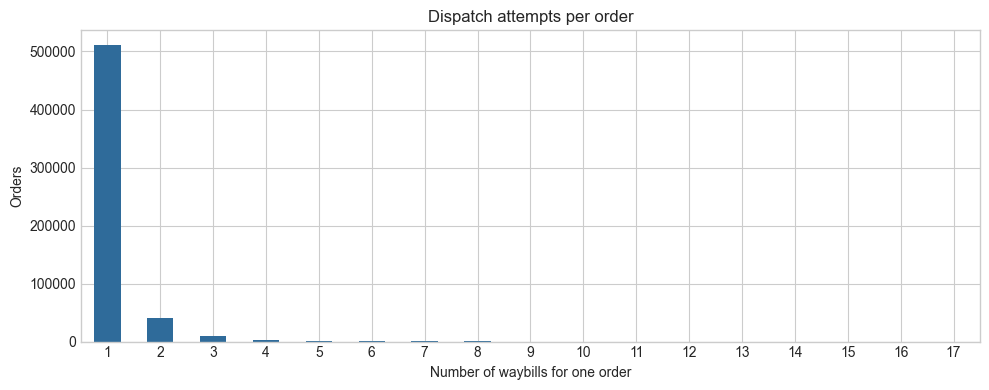

In [5]:
attempt_distribution = attempts_per_order.value_counts().sort_index()
ax = attempt_distribution.plot(kind="bar", figsize=(10, 4), color="#2F6B9A")
ax.set_title("Dispatch attempts per order")
ax.set_xlabel("Number of waybills for one order")
ax.set_ylabel("Orders")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**解释：** 官方业务流程允许骑手拒绝派单；订单会重新进入调度系统并生成新 `waybill_id`。因此订单分析的基础样本应从每单唯一的 `is_courier_grabbed = 1` 运单构造，拒绝运单保留用于研究派单次数与拒单问题，不能和最终履约结果重复计数。

## 3. 缺失值不是只有 `NaN`

公开数据用 `0` 表示部分事件未发生或信息不可用。下面同时检查真正空值和 `0` 编码。

In [6]:
focus_columns = [
    "courier_id", "da_id", "poi_id", "grab_lng", "grab_lat",
    "dispatch_time", "grab_time", "fetch_time", "arrive_time",
    "estimate_meal_prepare_time",
]
missing_profile = pd.DataFrame({
    "null_rate_pct": waybill[focus_columns].isna().mean().mul(100),
    "zero_rate_pct": waybill[focus_columns].eq(0).mean().mul(100),
}).round(4)
missing_profile

,null_rate_pct,zero_rate_pct
courier_id,0.0000,0.0050
da_id,0.0000,22.7561
poi_id,0.0000,0.1157
grab_lng,0.0000,13.1119
grab_lat,0.0000,13.1119
dispatch_time,0.0000,0.0002
grab_time,0.0000,13.1119
fetch_time,0.0000,13.1119
arrive_time,0.0000,13.1121
estimate_meal_prepare_time,0.0000,1.5140


In [7]:
sentinel_columns = ["grab_time", "fetch_time", "arrive_time", "grab_lng", "grab_lat"]
sentinel_consistency = (
    waybill.groupby("is_courier_grabbed", observed=True)
    .agg(
        rows=("order_id", "size"),
        **{
            f"{column}_zero_pct": (
                column,
                lambda values: round(values.eq(0).mean() * 100, 4),
            )
            for column in sentinel_columns
        },
    )
)
sentinel_consistency

,rows,grab_time_zero_pct,fetch_time_zero_pct,arrive_time_zero_pct,grab_lng_zero_pct,grab_lat_zero_pct
is_courier_grabbed,,,,,,
0,85797,100.0000,100.0000,100.0000,100.0000,100.0000
1,568546,0.0000,0.0000,0.0002,0.0000,0.0000


**一致性证据：** 未接单运单的接单、取餐、送达时间和接单位置均为 0；成功运单的这些字段基本完整，但仍有 1 条成功运单缺少送达时间。因此，0 值语义需要结合接单状态逐字段验证，不能只因两个总体比例相同就推断逐行一致。

**处理原则：** 不进行统一的“把 0 填均值”。每个字段按业务语义处理。例如，拒绝运单的 `grab_time/fetch_time/arrive_time = 0` 是事件未发生；`da_id = 0` 应作为“未知区域”单独标记，并在区域分析中做包含/排除敏感性检查。

## 4. 时间链路完整性与初步履约指标

这里只验证时间先后关系。`grab_time -> fetch_time` 的差值表示“接单到取餐”，由于缺少骑手到店时间，不能直接命名为“商家等待时长”。

In [8]:
time_pairs = [
    ("platform_order_time", "order_push_time"),
    ("order_push_time", "dispatch_time"),
    ("dispatch_time", "grab_time"),
    ("grab_time", "fetch_time"),
    ("fetch_time", "arrive_time"),
]

chronology = []
for start, end in time_pairs:
    eligible = accepted[start].gt(0) & accepted[end].gt(0)
    violations = eligible & accepted[start].gt(accepted[end])
    chronology.append({
        "check": f"{start} <= {end}",
        "eligible_rows": int(eligible.sum()),
        "violation_rows": int(violations.sum()),
        "violation_rate_pct": round(violations.sum() / eligible.sum() * 100, 4),
    })

pd.DataFrame(chronology)

,check,eligible_rows,violation_rows,violation_rate_pct
0,platform_order_time <= order_push_time,568546,0,0.0000
1,order_push_time <= dispatch_time,568545,0,0.0000
2,dispatch_time <= grab_time,568545,0,0.0000
3,grab_time <= fetch_time,568546,0,0.0000
4,fetch_time <= arrive_time,568545,0,0.0000


In [9]:
completed = accepted.loc[accepted["arrive_time"].gt(0) & accepted["estimate_arrived_time"].gt(0)].copy()
completed["is_on_time_preliminary"] = completed["arrive_time"].le(completed["estimate_arrived_time"])

daily_kpi = (
    completed.groupby("dt", observed=True)
    .agg(completed_orders=("order_id", "nunique"), on_time_rate=("is_on_time_preliminary", "mean"))
    .assign(on_time_rate_pct=lambda x: x["on_time_rate"].mul(100))
)
daily_kpi

,completed_orders,on_time_rate,on_time_rate_pct
dt,,,
20221017,66881,0.8662,86.6165
20221018,69102,0.8433,84.3348
20221019,68832,0.8503,85.0302
20221020,68830,0.8537,85.3668
20221021,72181,0.8410,84.0969
20221022,77638,0.8484,84.8360
20221023,77711,0.8339,83.3910
20221024,67370,0.8662,86.6157


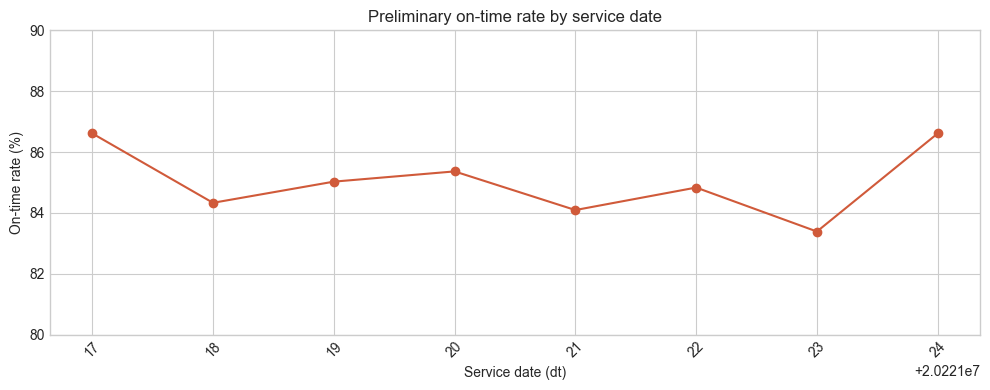

Preliminary overall on-time rate: 84.9919%
Completed orders used: 568,545


In [10]:
ax = daily_kpi["on_time_rate_pct"].plot(
    kind="line", marker="o", figsize=(10, 4), color="#D05A3A", ylim=(80, 90)
)
ax.set_title("Preliminary on-time rate by service date")
ax.set_xlabel("Service date (dt)")
ax.set_ylabel("On-time rate (%)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"Preliminary overall on-time rate: {completed['is_on_time_preliminary'].mean():.4%}")
print(f"Completed orders used: {len(completed):,}")

**边界：** 上述 84.99% 是数据验收值，不是最终汇报 KPI。正式分析还需明确：业务日期口径、跨日订单、预订单、异常 ETA、未知区域，以及是否用订单数或运单数作为分母。

## 5. 调度快照不能直接做订单—骑手匹配

官方说明：`dispatch_waybill` 是某决策时点待分配的订单集合，`dispatch_rider` 是同一时点候选骑手集合。两表共享决策时点，但不存在公开的实际匹配键。

In [11]:
orders_by_epoch = dispatch_waybill.groupby(["dt", "dispatch_time"], observed=True).size().rename("waiting_orders")
riders_by_epoch = dispatch_rider.groupby(["dt", "dispatch_time"], observed=True).size().rename("candidate_riders")
epoch_summary = pd.concat([orders_by_epoch, riders_by_epoch], axis=1)
epoch_summary["rows_if_naively_joined"] = epoch_summary["waiting_orders"] * epoch_summary["candidate_riders"]

display(epoch_summary.describe().round(2))
print(f"Decision epochs: {len(epoch_summary)}")
print(f"Rows after naive many-to-many join: {epoch_summary['rows_if_naively_joined'].sum():,}")
epoch_summary.head()

,waiting_orders,candidate_riders,rows_if_naively_joined
count,24.0000,24.0000,24.0000
mean,663.3800,"2,585.1700","1,715,488.5800"
std,38.4900,54.9000,"114,876.9500"
min,591.0000,"2,482.0000","1,506,459.0000"
25%,634.0000,"2,549.7500","1,625,835.5000"
50%,660.5000,"2,571.5000","1,696,411.0000"
75%,693.2500,"2,627.7500","1,800,888.0000"
max,733.0000,"2,680.0000","1,908,732.0000"


Decision epochs: 24
Rows after naive many-to-many join: 41,171,726


waiting_orders  candidate_riders  \
dt       dispatch_time                                     
20221017 1665977114                658              2503   
         1665977234                624              2557   
         1665977414                634              2571   
20221018 1666063506                710              2530   
         1666063626                645              2570   

                        rows_if_naively_joined  
dt       dispatch_time                          
20221017 1665977114                    1646974  
         1665977234                    1595568  
         1665977414                    1630014  
20221018 1666063506                    1796300  
         1666063626                    1657650

**正确用法：**

- 按 `dt + dispatch_time` 分别聚合供给与需求，构造时点级供需比；或
- 在空间网格内分别统计待派订单和候选骑手，构造网格—时点供需指标；
- 不声称公开数据提供了每个待派订单对应的候选骑手清单，也不把笛卡尔积当实际派单结果。

## 6. 骑手波次表覆盖检查

`order_ids` 是一个波次中被接受订单的列表。将其展开后，应与成功履约订单建立一对一覆盖关系。

In [12]:
def parse_order_ids(value):
    parsed = ast.literal_eval(value) if isinstance(value, str) else value
    return list(parsed)

wave_order_ids = courier_wave["order_ids"].map(parse_order_ids).explode().astype("int64")
accepted_in_wave = accepted["order_id"].isin(wave_order_ids)
accepted_missing_from_wave = accepted.loc[~accepted_in_wave]

wave_checks = pd.Series({
    "wave_rows": len(courier_wave),
    "unique_wave_composite_keys": courier_wave[["dt", "courier_id", "wave_id"]].drop_duplicates().shape[0],
    "order_references": len(wave_order_ids),
    "unique_order_references": wave_order_ids.nunique(),
    "accepted_orders": accepted["order_id"].nunique(),
    "wave_order_refs_found_in_accepted_pct": wave_order_ids.isin(accepted["order_id"]).mean() * 100,
    "accepted_orders_found_in_wave_pct": accepted_in_wave.mean() * 100,
    "accepted_orders_missing_from_wave": len(accepted_missing_from_wave),
    "missing_from_wave_with_zero_arrive_time": int(accepted_missing_from_wave["arrive_time"].eq(0).sum()),
    "wave_start_after_end_rows": int(courier_wave["wave_start_time"].gt(courier_wave["wave_end_time"]).sum()),
}, name="value")
wave_checks.to_frame()

,value
wave_rows,"206,748.0000"
unique_wave_composite_keys,"206,748.0000"
order_references,"568,545.0000"
unique_order_references,"568,545.0000"
accepted_orders,"568,546.0000"
wave_order_refs_found_in_accepted_pct,100.0000
accepted_orders_found_in_wave_pct,99.9998
accepted_orders_missing_from_wave,1.0000
missing_from_wave_with_zero_arrive_time,1.0000
wave_start_after_end_rows,0.0000


## 7. 本阶段结论与进入下一步的条件

**可以确认：**

- 四张表的基本粒度和候选主键通过检查；
- 每个订单恰好有一张成功运单，可以构造订单级履约宽表；
- 骑手波次表覆盖 568,545 个有完整送达记录的订单；
- 24 个派单时点可用于午高峰供需快照分析，但不能直接还原完整 8 天的实时运力变化。

**仍需冻结的口径：**

- 主分析样本是否排除预订单；
- `da_id = 0` 是否纳入区域排名；
- 跨业务日送达订单如何归属；
- 超时分层阈值、业务影响指标和运力建议的历史回放规则。

下一份 Notebook 将构造订单级分析宽表，并冻结样本准入、时间段、区域、距离与履约阶段指标。

## Sources

- Meituan-INFORMS-TSL Research Challenge official repository: https://github.com/meituan/Meituan-INFORMS-TSL-Research-Challenge
- Local official dataset paper: `data/raw/downloads/dataset_paper_2025.pdf`
- Local machine-generated audit: `outputs/raw_data_profile.json`